In [ ]:
import pandas as pd
import numpy as np

df=pd.read_csv("C:/Users/HP/cluster.csv")

In [ ]:
df

,GDP per Capita,Life Expectancy,Literacy Rate,Unemployment Rate,Access to Clean Water,Poverty Rate,Country
0,1548.813504,55.684339,68.209932,15.046955,61.354741,38.558033,Country 1
1,1715.189366,50.187898,60.971013,21.778165,62.982823,30.117141,Country 2
2,1602.763376,56.176355,68.379449,17.700080,65.699649,33.599781,Country 3
3,1544.883183,56.120957,60.960984,22.351940,65.908728,37.299906,Country 4
4,1423.654799,56.169340,69.764595,24.621885,65.743252,31.716297,Country 5
...,...,...,...,...,...,...,...
95,3490.305347,78.817202,89.067333,9.610557,86.334615,14.979623,Country 96
96,3989.409777,72.724369,90.520783,5.447473,94.805801,8.621891,Country 97
97,3065.304207,73.790569,87.716528,7.029712,93.717857,9.706489,Country 98
98,3783.234438,73.742962,89.554441,5.121566,90.027208,8.782452,Country 99


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   GDP per Capita         100 non-null    float64
 1   Life Expectancy        100 non-null    float64
 2   Literacy Rate          100 non-null    float64
 3   Unemployment Rate      100 non-null    float64
 4   Access to Clean Water  100 non-null    float64
 5   Poverty Rate           100 non-null    float64
 6   Country                100 non-null    object 
dtypes: float64(6), object(1)
memory usage: 5.6+ KB


In [ ]:
list(df)

['GDP per Capita',
 'Life Expectancy',
 'Literacy Rate',
 'Unemployment Rate',
 'Access to Clean Water',
 'Poverty Rate',
 'Country']

In [ ]:
features = df.drop('Country', axis=1)
features

,GDP per Capita,Life Expectancy,Literacy Rate,Unemployment Rate,Access to Clean Water,Poverty Rate
0,1548.813504,55.684339,68.209932,15.046955,61.354741,38.558033
1,1715.189366,50.187898,60.971013,21.778165,62.982823,30.117141
2,1602.763376,56.176355,68.379449,17.700080,65.699649,33.599781
3,1544.883183,56.120957,60.960984,22.351940,65.908728,37.299906
4,1423.654799,56.169340,69.764595,24.621885,65.743252,31.716297
...,...,...,...,...,...,...
95,3490.305347,78.817202,89.067333,9.610557,86.334615,14.979623
96,3989.409777,72.724369,90.520783,5.447473,94.805801,8.621891
97,3065.304207,73.790569,87.716528,7.029712,93.717857,9.706489
98,3783.234438,73.742962,89.554441,5.121566,90.027208,8.782452


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


In [ ]:
# draw a scatter plot of scaled_features to know the pattern of the data

<AxesSubplot:xlabel='Access to Clean Water', ylabel='Literacy Rate'>

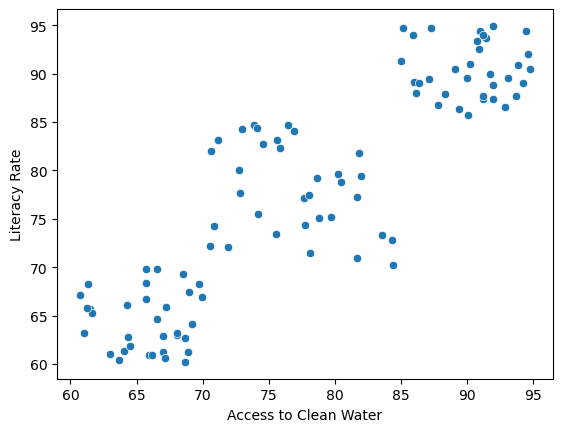

In [ ]:
import seaborn as sns
sns.scatterplot(x=df['Access to Clean Water'], y=df['Literacy Rate'])


## What Is the Random Initialization Trap?
Random Start: K-means begins by randomly selecting initial centroids from your data.

Impact: Different initial choices can lead to different final clusters,
which means your results can vary with each run.

# How to Mitigate It

## 1. n_clusters
What It Is: Number of clusters you want to divide your data into.


Example: If you set n_clusters=3, the algorithm will find 3 clusters in your data.
### 2. init
What It Is: Method for initializing the centroids (starting points) of the clusters.
Options:
'k-means++': A smarter way to pick initial centroids.
'random': Picks random points from the data.


Example: init='k-means++' often gives better results than random initialization.
### 3. n_init
What It Is: Number of times to run the K-means algorithm with different initial centroids.
Purpose: Helps find the best clustering result by trying multiple random starts.


Example: n_init=10 means K-means will run 10 times with different initial centroids and pick the best result.
### 4. max_iter
What It Is: Maximum number of iterations for each run of the K-means algorithm.
Purpose: Limits how long the algorithm will run to prevent it from running forever.


Example: max_iter=300 means the algorithm will stop if it doesn't converge within 300 iterations.


###  With n_init=2, K-Means will start with 2 different random sets of centroids.


### For each of these 2 sets, it will iterate up to 300 times if needed to converge.

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,init='k-means++',n_init=15)  # Example with 3 clusters
df['Cluster'] = kmeans.fit_predict(scaled_features)
df

,GDP per Capita,Life Expectancy,Literacy Rate,Unemployment Rate,Access to Clean Water,Poverty Rate,Country,Cluster
0,1548.813504,55.684339,68.209932,15.046955,61.354741,38.558033,Country 1,1
1,1715.189366,50.187898,60.971013,21.778165,62.982823,30.117141,Country 2,1
2,1602.763376,56.176355,68.379449,17.700080,65.699649,33.599781,Country 3,1
3,1544.883183,56.120957,60.960984,22.351940,65.908728,37.299906,Country 4,1
4,1423.654799,56.169340,69.764595,24.621885,65.743252,31.716297,Country 5,1
...,...,...,...,...,...,...,...,...
95,3490.305347,78.817202,89.067333,9.610557,86.334615,14.979623,Country 96,0
96,3989.409777,72.724369,90.520783,5.447473,94.805801,8.621891,Country 97,0
97,3065.304207,73.790569,87.716528,7.029712,93.717857,9.706489,Country 98,0
98,3783.234438,73.742962,89.554441,5.121566,90.027208,8.782452,Country 99,0


In [ ]:
# Profile each cluster
cluster_profile = df.groupby('Cluster').mean()
cluster_profile

,GDP per Capita,Life Expectancy,Literacy Rate,Unemployment Rate,Access to Clean Water,Poverty Rate
Cluster,,,,,,
0,3403.752586,75.323386,90.383698,7.228377,90.325159,10.329008
1,1573.592409,54.147094,64.442645,20.614254,65.780477,34.459943
2,2493.894997,64.452078,78.031502,12.203360,76.961105,25.848924


In [ ]:
df["Country"][df["Cluster"]==1] #POOR

0      Country 1
1      Country 2
2      Country 3
3      Country 4
4      Country 5
5      Country 6
6      Country 7
7      Country 8
8      Country 9
9     Country 10
10    Country 11
11    Country 12
12    Country 13
13    Country 14
14    Country 15
15    Country 16
16    Country 17
17    Country 18
18    Country 19
19    Country 20
20    Country 21
21    Country 22
22    Country 23
23    Country 24
24    Country 25
25    Country 26
26    Country 27
27    Country 28
28    Country 29
29    Country 30
30    Country 31
31    Country 32
32    Country 33
Name: Country, dtype: object

In [ ]:
df["Country"][df["Cluster"]==0] #RICH

66     Country 67
67     Country 68
68     Country 69
69     Country 70
70     Country 71
71     Country 72
72     Country 73
73     Country 74
74     Country 75
75     Country 76
76     Country 77
77     Country 78
78     Country 79
79     Country 80
80     Country 81
81     Country 82
82     Country 83
83     Country 84
84     Country 85
85     Country 86
86     Country 87
87     Country 88
88     Country 89
89     Country 90
90     Country 91
91     Country 92
92     Country 93
93     Country 94
94     Country 95
95     Country 96
96     Country 97
97     Country 98
98     Country 99
99    Country 100
Name: Country, dtype: object

In [ ]:


df


,GDP per Capita,Life Expectancy,Literacy Rate,Unemployment Rate,Access to Clean Water,Poverty Rate,Country,Cluster
0,1548.813504,55.684339,68.209932,15.046955,61.354741,38.558033,Country 1,1
1,1715.189366,50.187898,60.971013,21.778165,62.982823,30.117141,Country 2,1
2,1602.763376,56.176355,68.379449,17.700080,65.699649,33.599781,Country 3,1
3,1544.883183,56.120957,60.960984,22.351940,65.908728,37.299906,Country 4,1
4,1423.654799,56.169340,69.764595,24.621885,65.743252,31.716297,Country 5,1
...,...,...,...,...,...,...,...,...
95,3490.305347,78.817202,89.067333,9.610557,86.334615,14.979623,Country 96,0
96,3989.409777,72.724369,90.520783,5.447473,94.805801,8.621891,Country 97,0
97,3065.304207,73.790569,87.716528,7.029712,93.717857,9.706489,Country 98,0
98,3783.234438,73.742962,89.554441,5.121566,90.027208,8.782452,Country 99,0


<AxesSubplot:xlabel='GDP per Capita', ylabel='Literacy Rate'>

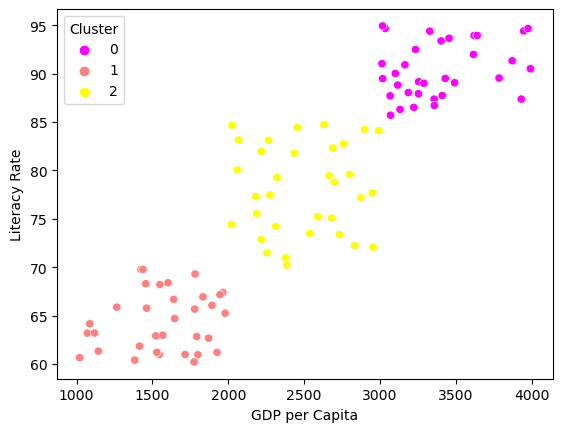

In [ ]:
sns.scatterplot(x=df['GDP per Capita'], y=df['Literacy Rate'],hue=df["Cluster"],palette="spring")


C:\Users\HP\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='GDP per Capita', ylabel='Life Expectancy'>

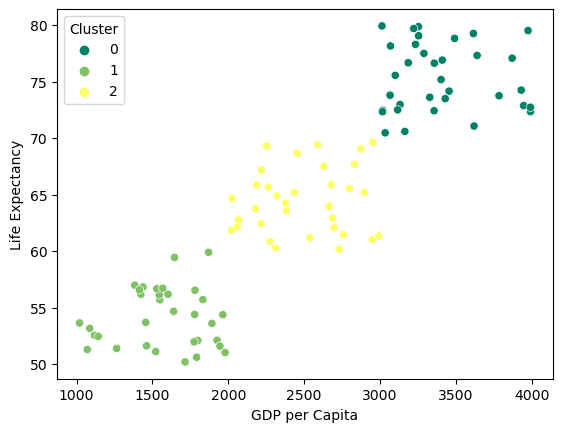

In [ ]:
sns.scatterplot(df['GDP per Capita'], df['Life Expectancy'], hue=df['Cluster'],palette="summer")


C:\Users\HP\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='GDP per Capita', ylabel='Life Expectancy'>

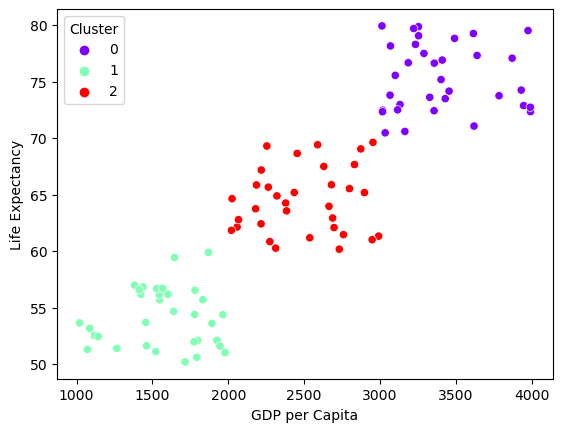

In [ ]:

sns.scatterplot(df['GDP per Capita'], df['Life Expectancy'], hue=df['Cluster'], palette='rainbow')


In [ ]:
df["Country"][df["Cluster"]==1]

0      Country 1
1      Country 2
2      Country 3
3      Country 4
4      Country 5
5      Country 6
6      Country 7
7      Country 8
8      Country 9
9     Country 10
10    Country 11
11    Country 12
12    Country 13
13    Country 14
14    Country 15
15    Country 16
16    Country 17
17    Country 18
18    Country 19
19    Country 20
20    Country 21
21    Country 22
22    Country 23
23    Country 24
24    Country 25
25    Country 26
26    Country 27
27    Country 28
28    Country 29
29    Country 30
30    Country 31
31    Country 32
32    Country 33
Name: Country, dtype: object

# Silhouette Score:

Measures how well data points are assigned to their clusters:


Values range from -1 to 1.


A higher score indicates well-separated clusters.

In [ ]:
labels = kmeans.labels_
labels

array([0, 3, 4, 8, 8, 0, 4, 3, 3, 0, 3, 0, 8, 3, 4, 4, 0, 8, 3, 8, 3, 3,
       4, 8, 4, 4, 4, 4, 0, 0, 4, 3, 4, 7, 2, 7, 2, 2, 2, 7, 7, 9, 7, 2,
       7, 7, 7, 2, 7, 2, 7, 2, 2, 9, 9, 7, 9, 2, 2, 2, 9, 7, 2, 7, 2, 9,
       1, 1, 1, 1, 1, 6, 1, 6, 5, 6, 6, 1, 6, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 5, 5, 5, 1, 1, 6, 5, 6, 1, 6, 1])

In [ ]:
#Evaluate Clustering

# Silhouette Score: Measure how well the clusters are separated.

from sklearn.metrics import silhouette_score
labels = kmeans.labels_
silhouette_avg = silhouette_score(scaled_features, labels)

print(silhouette_avg)

0.6316401554082066


# how can we know the number of clusters???

# elbow method

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)



In [ ]:
# Apply the Elbow Method to determine the optimal number of clusters
wcss = [] #y axis
k_values = range(1, 11)
# Check from 1 to 10 clusters,x axis
#[1,2,3,4,5,6,7,8,9,10]

for i in k_values:# i=1
    kmeans = KMeans(n_clusters=i) #i=1
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)



C:\Users\HP\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
kmeans.inertia_

38.338490153759075

In [ ]:
kmeans.labels_

array([0, 3, 4, 8, 8, 0, 4, 3, 3, 0, 3, 0, 8, 3, 4, 4, 0, 8, 3, 8, 3, 3,
       4, 8, 4, 4, 4, 4, 0, 0, 4, 3, 4, 7, 2, 7, 2, 2, 2, 7, 7, 9, 7, 2,
       7, 7, 7, 2, 7, 2, 7, 2, 2, 9, 9, 7, 9, 2, 2, 2, 9, 7, 2, 7, 2, 9,
       1, 1, 1, 1, 1, 6, 1, 6, 5, 6, 6, 1, 6, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 5, 5, 5, 1, 1, 6, 5, 6, 1, 6, 1])

In [ ]:
k_values

range(1, 11)

In [ ]:
wcss

[600.0,
 191.78640430474806,
 60.95739240634884,
 55.8951541669937,
 50.97411550438532,
 46.850301283600054,
 44.7787203432943,
 41.906940217783145,
 39.924330195799975,
 38.338490153759075]

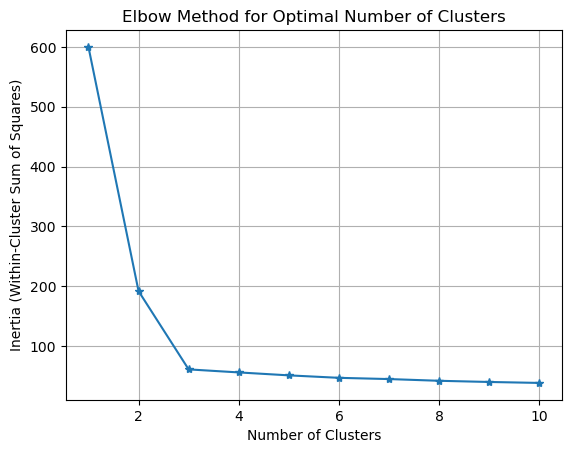

In [ ]:
import matplotlib.pyplot as plt
# Plot the Elbow curve
plt.plot(k_values, wcss,marker="*")
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.grid(True)
plt.show()

In [ ]:
x=[5,8]

In [ ]:
x.append(10)

In [ ]:
x

[5, 8, 10]

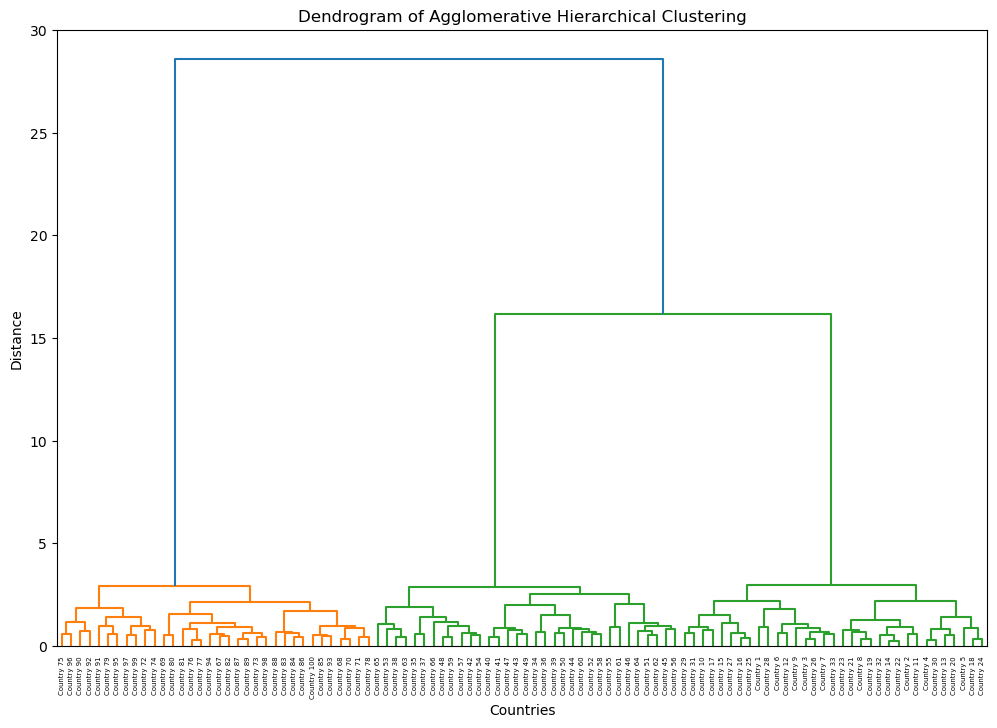

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Perform hierarchical clustering
Z = linkage(scaled_features, method='ward')

# Plot the dendrogram
plt.figure(figsize=(12, 8))
dendrogram(Z, labels=df['Country'].tolist(), leaf_rotation=90)
plt.title('Dendrogram of Agglomerative Hierarchical Clustering')
plt.xlabel('Countries')
plt.ylabel('Distance')
plt.show()
